# LSTM
LSTM (Long Short-Term Memory) : '단기기억'을 '오래' 기억하기

# IMDB 데이터 준비

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow import keras

import random
def set_seed(seed = 42):
  tf.keras.utils.set_random_seed(seed)
  tf.config.experimental.enable_op_determinism()

set_seed(42)

In [ ]:
base_path = r'/content/drive/MyDrive/out'

In [ ]:
# 이전 예제 처럼 IMDB  리뷰 데이터를 로드하고 훈련세트와 검증세트로 나눔
from tensorflow.keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=500)

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
max_len = 100

In [ ]:
# ↓ 각 샘플의 길이를 100에 맞추고 부족할때는 패딩을 추가
train_seq = pad_sequences(train_input, maxlen=max_len)
val_seq = pad_sequences(val_input, maxlen=max_len)
test_seq = pad_sequences(test_input, maxlen=max_len)

# ■ LSTM

**tf.keras.layers.LSTM**

https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM

```python
tf.keras.layers.LSTM(
    units,
    activation='tanh',
    recurrent_activation='sigmoid',
    use_bias=True,
    kernel_initializer='glorot_uniform',
    recurrent_initializer='orthogonal',
    bias_initializer='zeros',
    unit_forget_bias=True,
    kernel_regularizer=None,
    recurrent_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    recurrent_constraint=None,
    bias_constraint=None,
    dropout=0.0,
    recurrent_dropout=0.0,
    seed=None,
    return_sequences=False,
    return_state=False,
    go_backwards=False,
    stateful=False,
    unroll=False,
    use_cudnn='auto',
    **kwargs
)
```

In [ ]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(max_len,)))
model.add(keras.layers.Embedding(500, 16))
model.add(keras.layers.LSTM(units=8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
"""
Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │


│ lstm (LSTM)                     │ (None, 8)              │           800 │
        # ①입력 parameter : 16 inputs x 8 units = 128개
        # ②은닉상태 param  : 8 x 8 = 64개
        # ③bias   :   8 개

        # ④: ① + ② + ③ = 200개

        # 전체 parameter 는
        #  4 x ④200개 => 800개.
          #  ↑ 4 는 LSTM 셀 내의 각 게이트 (입력 게이트, 출력 게이트, 포겟 게이트, 셀 상태 업데이트)
          #    에 해당하는 파라미터의 개수

        ★LSTM의 파라미터 개수★
            => 4gates x units x (units + inputs + 1)
            => ex) 4 x 8 x (8 + 16 + 1) => 800


│ dense (Dense)                   │ (None, 1)              │             9 │

 Total params: 8,809 (34.41 KB)
 Trainable params: 8,809 (34.41 KB)
 Non-trainable params: 0 (0.00 B)

"""
None

In [ ]:
base_path = r'/content/drive/MyDrive/out'

In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    os.path.join(base_path, 'best-lstm-model.keras'),
    save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history = model.fit(train_seq, train_target, epochs=100, batch_size=64,
                    validation_data=(val_seq, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5110 - loss: 0.6929 - val_accuracy: 0.5864 - val_loss: 0.6911
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5784 - loss: 0.6907 - val_accuracy: 0.6258 - val_loss: 0.6874
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6217 - loss: 0.6858 - val_accuracy: 0.6562 - val_loss: 0.6765
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6681 - loss: 0.6682 - val_accuracy: 0.7096 - val_loss: 0.6177
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7180 - loss: 0.6006 - val_accuracy: 0.7248 - val_loss: 0.5760
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7282 - loss: 0.5690 - val_accuracy: 0.7404 - val_loss: 0.5555
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7481 - loss: 0.5465 - val_accuracy: 0.7450 - val_loss: 0.5383
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7600 - loss: 0.5274 - val_ac

In [ ]:
early_stopping_cb.best_epoch

48

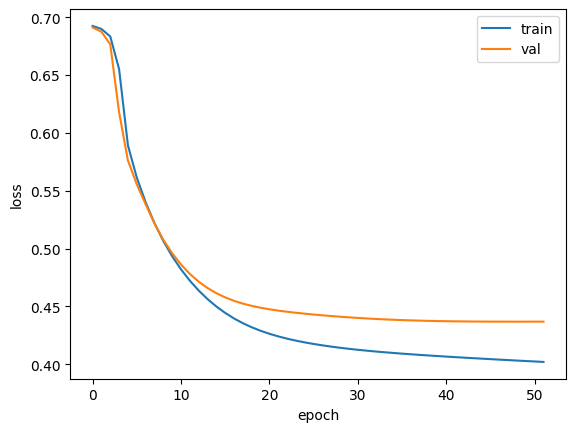

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# 순환층에 드롭아웃 적용

In [ ]:
# 완전연결신경망과 CNN 에서는 Dropout 클래스를 사용해서 dropout 을 적용했었다
# 순환층은 '자체적으로 dropout 기능을 제공'

# SimpleRNN, LSTM 클래스에 제공하는 2개의 dropout 매개변수
#   dropout= : 셀의 '입력'에 dropout 적용
#   recurrent_dropout= : 순환되는 '은닉상태'에 dropout 적용
#                        ※ recurrent_dropout 는 GPU를 통한 훈련 못함..

#  아래 예제에선 dropout= 만 사용함..

In [ ]:
model2 = keras.Sequential()
model2.add(keras.layers.Input(shape=(max_len,)))
model2.add(keras.layers.Embedding(500, 16))
model2.add(keras.layers.LSTM(units=8, dropout=0.3))  # dropout 30%
model2.add(keras.layers.Dense(1, activation='sigmoid'))

model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model2.compile(optimizer=rmsprop, loss='binary_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    os.path.join(base_path, 'best-dropout-model.keras'),
    save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history2 = model2.fit(train_seq, train_target, epochs=100, batch_size=64,
                    validation_data=(val_seq, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5083 - loss: 0.6929 - val_accuracy: 0.5342 - val_loss: 0.6921
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5544 - loss: 0.6918 - val_accuracy: 0.5756 - val_loss: 0.6906
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5943 - loss: 0.6896 - val_accuracy: 0.6104 - val_loss: 0.6867
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6256 - loss: 0.6840 - val_accuracy: 0.6522 - val_loss: 0.6718
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6738 - loss: 0.6577 - val_accuracy: 0.6930 - val_loss: 0.6071
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7014 - loss: 0.5944 - val_accuracy: 0.7148 - val_loss: 0.5795
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7215 - loss: 0.5701 - val_accuracy: 0.7304 - val_loss: 0.5571
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7443 - loss: 0.5457 - val_a

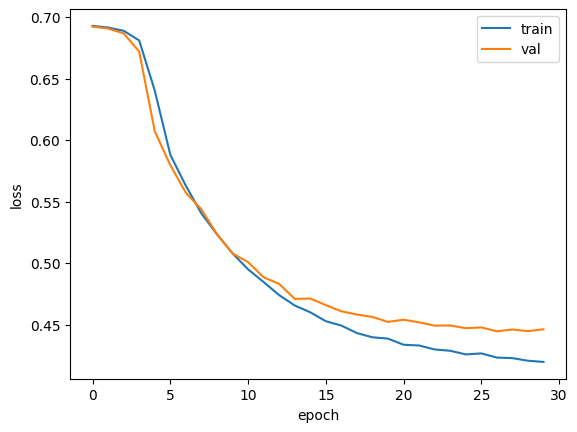

In [ ]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# ■ 순환층 2개 연결하기
### 순환층 연결시 주의!
- 순환층의 은닉상태는 샘플의 마지막 스텝에 대한 은닉 상태만 다음층으로 전달한다
- 그러나, 순환층을 쌓게 되면 모든 순환층에는 순차 데이터가 필요하다.
- 따라서
    - 앞쪽의 순환층은 '모든 타임스텝'에 대한 은닉상태를 출력해야 하고,
    - 마지막 순환층만 '마지막 타임스텝의 은닉상태'를 출력해야 한다

## return_sequences=True
모든 타임스텝에 대한 은닉상태 출력 (2차원 출력)

In [ ]:
model3 = keras.Sequential()
model3.add(keras.layers.Input(shape=(max_len,)))
model3.add(keras.layers.Embedding(500, 16))
model3.add(keras.layers.LSTM(units=8, dropout=0.3, return_sequences=True))
model3.add(keras.layers.LSTM(units=8, dropout=0.3))
model3.add(keras.layers.Dense(1, activation='sigmoid'))

model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 8)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,353 (36.54 KB)

 Trainable params: 9,353 (36.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
"""
Model: "sequential_3"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 8)         │           800 │
        # [출력크기]
        # 첫번째 LSTM 층이 모든 타입스텝 (100개) 의 은닉상태를 출력하기 때문에
        # 출력크기가 (?, 100, 8) 로 출력됨 (2차원 출력)

        # [첫번째 LSTM 의 parameter]
            => 4gates x units x (units + inputs + 1)
            => ex) 4 x 8 x (8 + 16 + 1) => 800


│ lstm_4 (LSTM)                   │ (None, 8)              │           544 │
        # [출력크기]
        # 마지막 LSTM 층의 출력크기는 마지막 타임스텝의 은닉상태만 출력하기 때문에
        # 출력크기가 (?, 8) 이다.

        # [두번째 LSTM 의 parameter]
        # 두 번째 LSTM의 경우, '첫 번째 LSTM의 출력'이 '두 번째 LSTM의 입력'이 됩니다.
        # 따라서 두 번째 LSTM의 입력 피처 수는 첫 번째 LSTM의 유닛 수와 동일
            => units x (units + inputs + 1)

       #  4 gates x 8 x (8 + 8 + 1) => 544

│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 9,353 (36.54 KB)
 Trainable params: 9,353 (36.54 KB)
 Non-trainable params: 0 (0.00 B)

"""
None

In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model3.compile(optimizer=rmsprop, loss='binary_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    os.path.join(base_path, 'best-2rnn-model.keras'),
    save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history3 = model3.fit(train_seq, train_target, epochs=100, batch_size=64,
                    validation_data=(val_seq, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.4988 - loss: 0.6931 - val_accuracy: 0.5272 - val_loss: 0.6929
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5298 - loss: 0.6927 - val_accuracy: 0.5560 - val_loss: 0.6920
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5581 - loss: 0.6913 - val_accuracy: 0.6024 - val_loss: 0.6870
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6155 - loss: 0.6818 - val_accuracy: 0.6604 - val_loss: 0.6441
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6767 - loss: 0.6232 - val_accuracy: 0.7078 - val_loss: 0.5778
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7129 - loss: 0.5722 - val_accuracy: 0.7240 - val_loss: 0.5578
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7402 - loss: 0.5411 - val_accuracy: 0.7394 - val_loss: 0.5328
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7541 - loss: 0.5205 - 

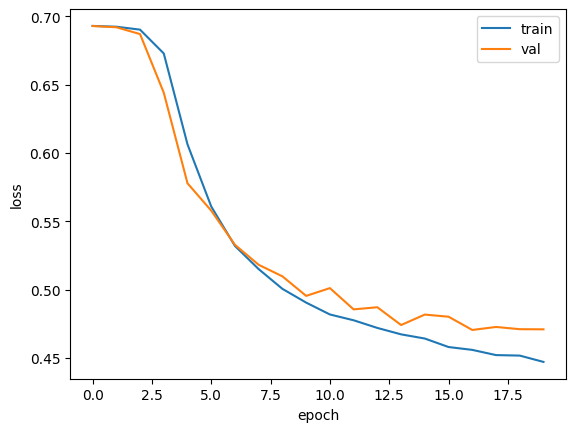

In [ ]:
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# ■ GRU 신경망
Gated Recurrent Unit

https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU

```python
tf.keras.layers.GRU(
    units,
    activation='tanh',
    recurrent_activation='sigmoid',
    use_bias=True,
    kernel_initializer='glorot_uniform',
    recurrent_initializer='orthogonal',
    bias_initializer='zeros',
    kernel_regularizer=None,
    recurrent_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    recurrent_constraint=None,
    bias_constraint=None,
    dropout=0.0,
    recurrent_dropout=0.0,
    seed=None,
    return_sequences=False,
    return_state=False,
    go_backwards=False,
    stateful=False,
    unroll=False,
    reset_after=True,
    use_cudnn='auto',
    **kwargs
)
```

In [ ]:
model4 = keras.Sequential()
model4.add(keras.layers.Input(shape=(max_len,)))
model4.add(keras.layers.Embedding(500, 16))
model4.add(keras.layers.GRU(units=8))
model4.add(keras.layers.Dense(1, activation='sigmoid'))

model4.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 8)              │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,633 (33.72 KB)

 Trainable params: 8,633 (33.72 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
"""
Model: "sequential_4"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 8)              │           624 │

      # 입력 parameter : 16 inputs x 8 units = 128개
      # 은닉상태 param : 8 x 8 = 64개
      # bias 가 뉴런마다 : 8개

      # 합하면 200개
      # 이런셀이 3개  200 * 3 => 600개?

      # TF GRU 는 내부적으로 작은 셀마다 하나의 bias 가 추가됨.
      #  작은셀3개 x 8개 units = 24개.


│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 8,633 (33.72 KB)
 Trainable params: 8,633 (33.72 KB)
 Non-trainable params: 0 (0.00 B)
"""
None

In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model4.compile(optimizer=rmsprop, loss='binary_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    os.path.join(base_path, 'best-gru-model.keras'),
    save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history4 = model4.fit(train_seq, train_target, epochs=100, batch_size=64,
                    validation_data=(val_seq, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5027 - loss: 0.6929 - val_accuracy: 0.5314 - val_loss: 0.6922
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5577 - loss: 0.6912 - val_accuracy: 0.5606 - val_loss: 0.6902
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5765 - loss: 0.6888 - val_accuracy: 0.5808 - val_loss: 0.6872
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5947 - loss: 0.6853 - val_accuracy: 0.5900 - val_loss: 0.6829
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6075 - loss: 0.6801 - val_accuracy: 0.5990 - val_loss: 0.6768
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6183 - loss: 0.6728 - val_accuracy: 0.6122 - val_loss: 0.6685
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6281 - loss: 0.6629 - val_accuracy: 0.6254 - val_loss: 0.6575
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6451 - loss: 0.6498 - val_ac

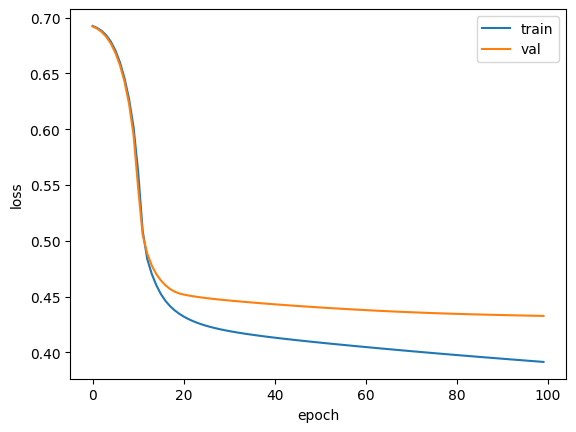

In [ ]:
plt.plot(history4.history['loss'])
plt.plot(history4.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
# 테스트셋 평가
rnn_model = keras.models.load_model(os.path.join(base_path, 'best-gru-model.keras'))
rnn_model.evaluate(test_seq, test_target)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8030 - loss: 0.4304


[0.429179847240448, 0.8023599982261658]

# ■ 양방향 LSTM
Bidirectional-LSTM, Bi-LSTM
RNN 이나 LSTM 은 일반 신경망과 다르게 시퀀스 또는 시계열 데이터 처리에 특화되어 은닉층에서 과거의 정보를 기억할 수 있습니다.  그러나, 순환 신경망의 구조적 특성상 데이터가 **'입력 순'** 으로 처리되기 때문에 이전 시점의 정보만 활용할 수 밖에 없는 단점이 존재합니다.  문장이 길어 질수록(시퀀스가 길어질수록) 성능이 저하될 수 밖에 없습니다. 다음 예문을 봅시다

> ios 앱 <u>[   ]</u>은 맥북이 필요합니다

> ios 앱 <u>개발</u>은 맥북이 필요합니다

한국어를 사용하는 우리에겐 어렵지 않게 빈칸에 들어가는 단어를 유추해낼수 있다.  그러나 일반적인 RNN 이나 LSTM 에서 순차적으로 입력되는 시퀀스를 통해 앞에 입력된 데이터인 'ios' 와 '앱' 이라는 단어만 가지고 빈칸에 들어갈 '개발' 이라는 단어를 유추해 내기엔 정보가 매우 부족하다.

문장 **앞부분보단, 뒷부분에 중요한 정보**가 존재하기 때문입니다.

따라서! 자연어 처리에서 입력 데이터의 '정방향' 처리만큼 **'역방향'** 처리도 중요합니다!

**양방향 LSTM (Bidirectional LSTM)** 은 기존 LSTM 계측에 역방향으로 처리하는  LSTM 계층을 하나 더 추가해 양방향에서 문장의 패턴을 분석할수 있도록 구성되어 있습니다.  입력 문장을 양방향에서 처리하므로 시퀀스 길이가 길어진다 하더라도 정보 손실 없이 처리가 가능


**양방향 LSTM 구조**

![](https://blog.kakaocdn.net/dn/ySdrH/btrZrwllBAV/T6RqmCYAkavMJ1iZ2gTi80/img.png)

## Bidirectional
**tf.keras.layers.Bidirectional**
- RNN 에 적용하는 양방향 (bidirectional) wrapper
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/Bidirectional
- Bidirectional 로 설정할 RNN layer 는 **return_sequences=True**: 모든 time step 에서 출력을 반환해야 하므로 설정해야 한다

```python
tf.keras.layers.Bidirectional(
    layer,
    merge_mode='concat',
    weights=None,
    backward_layer=None,
    **kwargs
)
```





## TimeDistributed
**tf.keras.layers.TimeDistributed**
- 각 time step 에서 출력된 output 을 내부에 선언해준 레이어와 연결시켜주는 역할
- TimeDistributed 또한 Wrapper 다 (Wrapper 상속객체)
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/TimeDistributed
- 출력 형태는 (batch_size, time_steps, num_classes)

```python
tf.keras.layers.TimeDistributed(
    layer, **kwargs
)
```



양방향 LSTM 모델을 정의할때 주의점!
- 정방향, 역방향 LSTM 계측 모두 출력값을 연결해야 하기 때문에, return_sequences 인자를 반드시 True 로 해야 함.
- 또한 Dense 계층을 TimeDistributed 래퍼를 사용해 3차원 텐서를 입력받을수 있게 확장해야 한다

## 모델 정의

In [ ]:
from tensorflow.keras.layers import Bidirectional, Embedding, \
                Input, LSTM, TimeDistributed, Dense, Flatten

In [ ]:
model5 = keras.Sequential()

model5.add(Input(shape=(max_len,)))  # (100,)
model5.add(Embedding(input_dim=500, output_dim=16))
model5.add(Bidirectional(LSTM(8, dropout=0.3, return_sequences=True)))
model5.add(TimeDistributed(Dense(1, activation='sigmoid')))
model5.add(Flatten())
model5.add(Dense(1, activation='sigmoid'))

model5.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 16)        │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 1)         │            17 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,718 (37.96 KB)

 Trainable params: 9,718 (37.96 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model5.compile(optimizer=rmsprop, loss='binary_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    os.path.join(base_path, 'best-biLSTM-model.keras'),
    save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history5 = model5.fit(train_seq, train_target, epochs=100, batch_size=64,
                    validation_data=(val_seq, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.5033 - loss: 0.6942 - val_accuracy: 0.5126 - val_loss: 0.6931
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5006 - loss: 0.6932 - val_accuracy: 0.5114 - val_loss: 0.6931
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.4993 - loss: 0.6932 - val_accuracy: 0.5088 - val_loss: 0.6931
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.5011 - loss: 0.6932 - val_accuracy: 0.5108 - val_loss: 0.6931
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4992 - loss: 0.6932 - val_accuracy: 0.5132 - val_loss: 0.6931
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5063 - loss: 0.6931 - val_accuracy: 0.5060 - val_loss: 0.6931
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5029 - loss: 0.6932 - val_accuracy: 0.5146 - val_loss: 0.6930
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5048 - loss: 0.6931

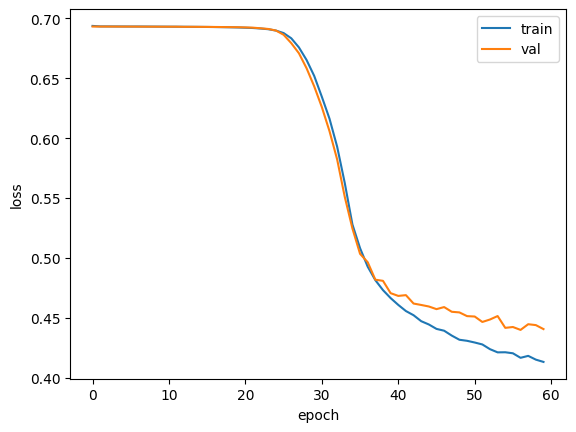

In [ ]:
plt.plot(history5.history['loss'])
plt.plot(history5.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()